In [81]:
# Original data extraction and filtering steps (kept for reference)
'''
import pandas as pd
import time

all_dfs = []

for start_year in range(2006, 2026, 2):  # po 2 rokoch
    end_year = start_year + 1
    url = (
        f"https://earthquake.usgs.gov/fdsnws/event/1/query.csv?"
        f"format=csv&starttime={start_year}-01-01&endtime={end_year}-12-31"
        f"&minmagnitude=4.5&orderby=time&limit=20000"
    )

    print(f"Downloading {start_year}-{end_year} ...")
    df = pd.read_csv(url)
    all_dfs.append(df)
    print(f"Years {start_year}-{end_year}: {len(df)} records")
    time.sleep(1)  # pauza pre server

# All dfs together
earthquakes = pd.concat(all_dfs, ignore_index=True)

# Extracted just a year form a date
earthquakes['year'] = pd.to_datetime(earthquakes['time']).dt.year

# Yearly counts
yearly_counts = earthquakes.groupby('year').size().reset_index(name='count')

# Create a new DataFrame with the desired columns
final_df = yearly_counts[['year', 'count']].rename(columns={'count':'M≥4.5'})

# Save the final DataFrame to a CSV file
final_df.to_csv("earthquake_counts_by_year.csv", index=False)
print("CSV saved: earthquake_counts_by_year.csv")
print(final_df)
print(len(earthquakes))'''

'\nimport pandas as pd\nimport time\n\nall_dfs = []\n\nfor start_year in range(2006, 2026, 2):  # po 2 rokoch\n    end_year = start_year + 1\n    url = (\n        f"https://earthquake.usgs.gov/fdsnws/event/1/query.csv?"\n        f"format=csv&starttime={start_year}-01-01&endtime={end_year}-12-31"\n        f"&minmagnitude=4.5&orderby=time&limit=20000"\n    )\n\n    print(f"Downloading {start_year}-{end_year} ...")\n    df = pd.read_csv(url)\n    all_dfs.append(df)\n    print(f"Years {start_year}-{end_year}: {len(df)} records")\n    time.sleep(1)  # pauza pre server\n\n# All dfs together\nearthquakes = pd.concat(all_dfs, ignore_index=True)\n\n# Extracted just a year form a date\nearthquakes[\'year\'] = pd.to_datetime(earthquakes[\'time\']).dt.year\n\n# Yearly counts\nyearly_counts = earthquakes.groupby(\'year\').size().reset_index(name=\'count\')\n\n# Create a new DataFrame with the desired columns\nfinal_df = yearly_counts[[\'year\', \'count\']].rename(columns={\'count\':\'M≥4.5\'})\n\n#

# Introduction

This project investigates whether the number of **earthquakes with a magnitude of M ≥ 4.5** has changed between two ten‑year periods: **2006–2015 and 2016–2025.** Across the full 20‑year interval, a **total of 147,664** such earthquakes were recorded. The first decade accounts for **73,307** events (mean 7,330.7 per year), while the second decade contains **74,357** events (mean 7,435.7 per year).

The second period shows a slight increase in both total and average annual counts. The goal of this analysis is to determine whether this increase represents a meaningful change in seismic activity.

**Hypothesis:**
The second period does not differ meaningfully from the first period in the number of earthquakes with magnitude M ≥ 4.5.

**Formal notation:**

**H₀:** There is no difference between the two periods in earthquake counts.

**H₁:** The two periods differ in earthquake counts.

A line plot is first used for visual inspection, followed by three statistical tests examining differences in distribution, average rate, and variability of annual earthquake counts.

In [82]:
import pandas as pd
final_df = pd.read_csv("earthquake_counts_by_year.csv")

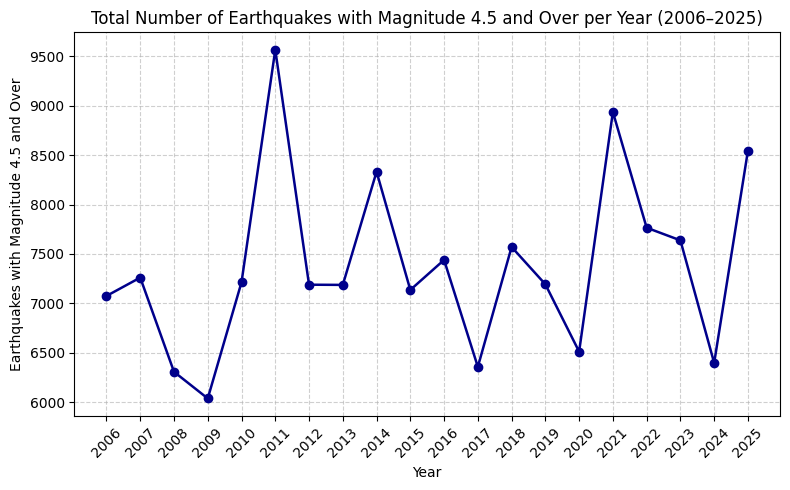

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(final_df['year'], final_df['M≥4.5'], color='darkblue', marker='o', linewidth=1.8)
plt.xlabel('Year')
plt.ylabel('Earthquakes with Magnitude 4.5 and Over')
plt.title('Total Number of Earthquakes with Magnitude 4.5 and Over per Year (2006–2025)')
plt.grid(True, linestyle='--', alpha=0.6)

# years (ticks) as integer
plt.xticks(final_df['year'])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
plt.close()

## Line Graph – Interpretation

The line graph shows the annual number of earthquakes with magnitude M ≥ 4.5 across the two periods (2006–2015 and 2016–2025). Although the yearly counts fluctuate, **the overall pattern does not indicate any clear upward or downward trend.** Both decades display natural year‑to‑year variability, with occasional peaks and dips, but without a consistent directional change.

This visual inspection suggests that the two periods may be similar in terms of overall seismic activity, which motivates the need for statistical testing to determine whether any observed differences are meaningful.

In [84]:
# Datates to two periods
period1 = final_df[(final_df['year'] >= 2006) & (final_df['year'] <= 2015)]['M≥4.5']
period2 = final_df[(final_df['year'] >= 2016) & (final_df['year'] <= 2025)]['M≥4.5']

<hr>

# Mann–Whitney U Test

**Why this test?**

The Mann–Whitney U test is a non‑parametric test used to compare whether two independent samples come from the same distribution. It is appropriate here because annual earthquake counts are not normally distributed and the sample size for each period is relatively small (10 years per group). The test allows us to evaluate whether the overall distribution of yearly counts differs between the two decades.

In [85]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(period1, period2, alternative='two-sided')
print(f"Mann–Whitney U stat={stat}, p-value={p}")

Mann–Whitney U stat=38.0, p-value=0.3846730627355087


**Interpretation of Results**

The test returned the following values:

**U statistic: 38.0**

**p‑value: 0.3847**

Since the p‑value is well above the conventional significance threshold of 0.05, we **do not have evidence to reject the null hypothesis.** This means that the distribution of annual earthquake counts in the second period (2016–2025) does not differ significantly from the distribution in the first period (2006–2015).

In other words, based on this test, the two decades appear similar in terms of their overall yearly earthquake counts.

<hr>

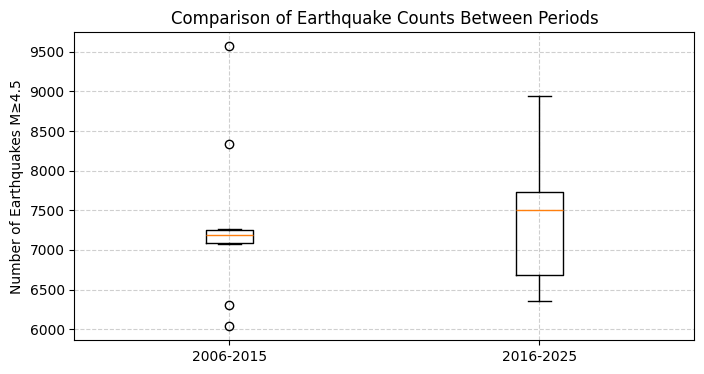

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.boxplot([period1, period2], tick_labels=['2006-2015', '2016-2025'])
plt.ylabel('Number of Earthquakes M≥4.5')
plt.title('Comparison of Earthquake Counts Between Periods')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Boxplot – Interpretation

The boxplot compares the distribution of annual earthquake counts between the two periods. The second decade shows a noticeably wider spread, with a higher median and more extended whiskers. While the first period is relatively compact (with most values clustered between roughly 7,100 and 7,300), **the second period spans a broader range**, from around 6,700 to 7,800, with whiskers extending approximately from 6,400 up to 8,900.

This visual pattern suggests greater variability in the second decade. In the next step, a statistical test is used to determine whether this apparent difference in spread is meaningful or simply a visual impression.

<hr>

## Poisson Rate Test

**Why this test?**

The Poisson rate test is used to compare the average rate at which events occur over time. Because earthquake counts represent discrete events that can be modelled as Poisson processes, this test is appropriate for evaluating whether the mean annual rate of earthquakes differs between the two decades.

In [87]:
from statsmodels.stats.rates import test_poisson_2indep

# Sums for periods
count1 = period1.sum()   # 2006–2015
count2 = period2.sum()   # 2016–2025

# Length of period
time1 = len(period1)
time2 = len(period2)

# Poisson rate test (two-sided)
result = test_poisson_2indep(count1, count2, time1, time2,
                             method='score', alternative='two-sided')

print(result)

statistic = -0.04497032500744897
pvalue = 0.9641309622288585
distribution = normal
compare = ratio
method = score
alternative = two-sided
rates = (np.float64(0.985878935406216), np.float64(1.0))
ratio = 0.985878935406216
diff = -0.014121064593784038
value = 1
rates_cmle = None
ratio_null = 1
tuple = (np.float64(-0.04497032500744897), np.float64(0.9641309622288585))


**Interpretation of Results**

The test produced the following key values:

* Rate ratio: 0.9859

* Difference in rates: −0.0141

* Test statistic: −0.04497

* p‑value: 0.9641

The p‑value is far above the conventional significance threshold of 0.05, indicating that **we do not have evidence to reject the null hypothesis.** In practical terms, this means that the average annual rate of earthquakes with magnitude M ≥ 4.5 is statistically indistinguishable between the two periods.

Although the raw data show a slight increase in the second decade, the Poisson rate test confirms that this difference is not statistically meaningful. The two decades therefore appear similar in terms of their underlying earthquake occurrence rate.

<hr>

## Brown–Forsythe Test

**Why this test?**

The Brown–Forsythe test is a robust method for comparing the variability of two groups. It is particularly useful when the data may not follow a normal distribution, which is the case for annual earthquake counts. This test evaluates whether the spread (variance) of yearly earthquake counts differs between the two decades.

In [88]:
from scipy.stats import levene

stat, p = levene(period1, period2, center='median')
print(f"Brown–Forsythe stat={stat}, p-value={p}")

Brown–Forsythe stat=0.05930309431187442, p-value=0.81035461521563


**Interpretation of Results**

The test returned the following values:

* Statistic: 0.0593

* p‑value: 0.8104

Since the p‑value is much higher than the standard significance threshold of 0.05, **we do not have evidence to conclude that the variability of annual earthquake counts differs between the two periods.**

Although the boxplot visually suggests a wider spread in the second decade, the Brown–Forsythe test indicates that this difference is not statistically significant. In other words, the apparent increase in variability is not strong enough to be considered meaningful from a statistical perspective.

<hr>

# Conclusion

This analysis examined whether the number of earthquakes with magnitude M ≥ 4.5 changed meaningfully between the periods 2006–2015 and 2016–2025. Visual inspection through a line graph showed no clear long‑term trend, while the boxplot indicated a higher median and greater spread in the second decade.

To evaluate these observations statistically, three tests were applied.
The Mann–Whitney U test showed no significant difference in the overall distribution of annual earthquake counts between the two periods.
The Poisson rate test indicated that the average annual rate of earthquakes is statistically indistinguishable across decades, despite the slight increase observed in the raw data.
Finally, the Brown–Forsythe test found no significant difference in variability, suggesting that the wider spread seen in the boxplot is not statistically meaningful.

Taken together, the results consistently support the conclusion that the **two decades do not differ in a statistically significant way in terms of the frequency or variability of earthquakes with magnitude M ≥ 4.5.** The apparent differences observed visually are within the range of natural year‑to‑year variability.

*It is important to note that this project evaluates only the frequency of earthquakes with M ≥ 4.5. It does not analyse how earthquake magnitudes may have changed over time. Therefore, the results should not be interpreted as evidence that seismic intensity or the severity of natural hazards has remained constant; such questions would require a separate analysis focused on magnitude distributions.*

In [89]:
!jupyter nbconvert hypothesis.ipynb --to html --no-input

[NbConvertApp] Converting notebook hypothesis.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 441824 bytes to hypothesis.html
